In [1]:
import pandas as pd

df = pd.read_csv('data/house_prices.csv')

print(df.shape)
df.head()

(187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [2]:
df.columns.tolist()


['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [3]:
for col in ['Amount(in rupees)', 'Price (in rupees)', 'Carpet Area', 'Super Area', 'Plot Area', 'Floor', 'Dimensions']:
    print(f"--- {col} ---")
    print(df[col].dropna().unique()[:10])
    print()
    

--- Amount(in rupees) ---
<StringArray>
[  '42 Lac ',   '98 Lac ',  '1.40 Cr ',   '25 Lac ',  '1.60 Cr ',   '45 Lac ',
 '16.5 Lac ',   '60 Lac ',  '1.36 Cr ',  '1.35 Cr ']
Length: 10, dtype: str

--- Price (in rupees) ---
[ 6000. 13799. 17500. 18824.  6618.  2538. 10435. 10000. 11150. 12174.]

--- Carpet Area ---
<StringArray>
[ '500 sqft',  '473 sqft',  '779 sqft',  '530 sqft',  '635 sqft',  '550 sqft',
  '900 sqft',  '950 sqft', '1820 sqft',  '675 sqft']
Length: 10, dtype: str

--- Super Area ---
<StringArray>
[ '680 sqft',  '575 sqft',  '600 sqft', '1165 sqft',  '844 sqft',  '650 sqft',
  '540 sqft',  '520 sqft',  '525 sqft',  '580 sqft']
Length: 10, dtype: str

--- Plot Area ---
[]

--- Floor ---
<StringArray>
[   '10 out of 11',     '3 out of 22',    '10 out of 29',      '1 out of 3',
    '20 out of 42',      '2 out of 7',      '4 out of 5', 'Ground out of 7',
 'Ground out of 2',     '3 out of 27']
Length: 10, dtype: str

--- Dimensions ---
[]



In [4]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [5]:
import re

def convert_amount(value):
    if pd.isna(value):
        return None
    value = value.strip()
    match = re.match(r'([\d.]+)\s*(Lac|Cr)', value, re.IGNORECASE)
    if not match:
        return None
    number, unit = match.groups()
    number = float(number)
    if unit.lower() == 'lac':
        return number * 100_000
    elif unit.lower() == 'cr':
        return number * 10_000_000
    return None

df['price_rupees'] = df['Amount(in rupees)'].apply(convert_amount)
df[['Amount(in rupees)', 'price_rupees']].head(10)

,Amount(in rupees),price_rupees
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [6]:
df['price_rupees'].isnull().sum()
df['price_rupees'].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_rupees, dtype: float64

In [7]:
failed = df[df['price_rupees'].isnull()]['Amount(in rupees)'].unique()
print(len(failed))
failed[:20]

1


<StringArray>
['Call for Price']
Length: 1, dtype: str

In [8]:
df.nlargest(10, 'price_rupees')[['Amount(in rupees)', 'price_rupees']]

,Amount(in rupees),price_rupees
181234,1400.30 Cr,1.400300e+10
176536,510.04 Cr,5.100400e+09
174894,396.75 Cr,3.967500e+09
175013,229.80 Cr,2.298000e+09
183303,80 Cr,8.000000e+08
51966,60 Cr,6.000000e+08
50321,55 Cr,5.500000e+08
52058,55 Cr,5.500000e+08
52387,52 Cr,5.200000e+08
51965,50 Cr,5.000000e+08


In [9]:
df['price_rupees'].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.999])

0.010      1600000.0
0.050      2250000.0
0.500      7800000.0
0.950     33900000.0
0.990     70000000.0
0.999    125000000.0
Name: price_rupees, dtype: float64

In [10]:
df = df[df['Amount(in rupees)'] != 'Call for Price']

In [11]:
upper_limit = df['price_rupees'].quantile(0.99)
print(f"Upper limit (99th percentile): {upper_limit:,.0f}")

df = df[df['price_rupees'] <= upper_limit]
print(df.shape)

Upper limit (99th percentile): 70,000,000
(176665, 22)


In [12]:
df['price_rupees'].describe()

count    1.766650e+05
mean     1.119450e+07
std      1.029408e+07
min      1.000000e+05
25%      4.800000e+06
50%      7.700000e+06
75%      1.400000e+07
max      7.000000e+07
Name: price_rupees, dtype: float64

In [13]:
def extract_sqft(value):
    if pd.isna(value):
        return None
    match = re.search(r'([\d.]+)', str(value))
    if match:
        return float(match.group(1))
    return None

df['carpet_area_sqft'] = df['Carpet Area'].apply(extract_sqft)
df['super_area_sqft'] = df['Super Area'].apply(extract_sqft)

df[['Carpet Area', 'carpet_area_sqft', 'Super Area', 'super_area_sqft']].head(10)

,Carpet Area,carpet_area_sqft,Super Area,super_area_sqft
0,500 sqft,500.0,NaN,NaN
1,473 sqft,473.0,NaN,NaN
2,779 sqft,779.0,NaN,NaN
3,530 sqft,530.0,NaN,NaN
4,635 sqft,635.0,NaN,NaN
5,NaN,NaN,680 sqft,680.0
6,550 sqft,550.0,NaN,NaN
7,NaN,NaN,575 sqft,575.0
8,NaN,NaN,600 sqft,600.0
9,900 sqft,900.0,NaN,NaN


In [14]:
print(df['carpet_area_sqft'].isnull().sum(), '/', len(df))
print(df['super_area_sqft'].isnull().sum(), '/', len(df))

df[['carpet_area_sqft', 'super_area_sqft']].describe()

76108 / 176665
100647 / 176665


,carpet_area_sqft,super_area_sqft
count,100557.000000,76018.000000
mean,1198.978152,1304.839209
std,3116.483368,654.904611
min,1.000000,1.000000
25%,770.000000,950.000000
50%,1050.000000,1255.000000
75%,1500.000000,1650.000000
max,709222.000000,9450.000000


In [15]:
df['area_sqft'] = df['carpet_area_sqft'].fillna(df['super_area_sqft'])

print(df['area_sqft'].isnull().sum(), '/', len(df))
df['area_sqft'].describe()

90 / 176665


count    176575.000000
mean       1244.552813
std        2391.335474
min           1.000000
25%         830.000000
50%        1150.000000
75%        1551.000000
max      709222.000000
Name: area_sqft, dtype: float64

In [16]:
df['area_sqft'].quantile([0.95, 0.99, 0.999, 1.0])

0.950      2440.0
0.990      3600.0
0.999      5000.0
1.000    709222.0
Name: area_sqft, dtype: float64

In [17]:
area_upper_limit = df['area_sqft'].quantile(0.999)
print(f"Upper limit: {area_upper_limit}")

df = df[df['area_sqft'] <= area_upper_limit]
print(df.shape)

Upper limit: 5000.0
(176402, 25)


In [18]:
df = df.dropna(subset=['area_sqft'])
print(df.shape)

(176402, 25)


In [19]:
df['area_sqft'].describe()

count    176402.000000
mean       1224.808568
std         654.723106
min           1.000000
25%         830.000000
50%        1150.000000
75%        1551.000000
max        5000.000000
Name: area_sqft, dtype: float64

In [20]:
df['Floor'].dropna().unique()[:30]

<StringArray>
[   '10 out of 11',     '3 out of 22',    '10 out of 29',      '1 out of 3',
    '20 out of 42',      '2 out of 7',      '4 out of 5', 'Ground out of 7',
 'Ground out of 2',     '3 out of 27',     '6 out of 20',    '16 out of 24',
     '8 out of 20',    '18 out of 27',      '2 out of 3',    '10 out of 16',
      '5 out of 7',    '20 out of 28',      '3 out of 3',      '3 out of 7',
    '15 out of 31',     '2 out of 28',    '27 out of 27',      '5 out of 5',
      '3 out of 8',    '11 out of 17',     '9 out of 24',    '16 out of 27',
    '14 out of 29',    '12 out of 27']
Length: 30, dtype: str

In [21]:
# نتأكد من كل الصيغ الفريدة (مش بس أول 30)
unique_floors = df['Floor'].dropna().unique()
print(len(unique_floors))

# نشوف أي صيغة مش بالشكل "رقم/Ground out of رقم"
import re
pattern = re.compile(r'^(Ground|\d+)\s+out\s+of\s+(\d+)$')
unusual = [f for f in unique_floors if not pattern.match(str(f))]
print(len(unusual))
unusual[:30]

886
56


['Upper Basement out of 9',
 'Lower Basement out of 7',
 'Upper Basement out of 7',
 'Upper Basement out of 4',
 'Upper Basement out of 8',
 'Lower Basement out of 6',
 '2',
 'Upper Basement out of 10',
 'Upper Basement out of 22',
 'Upper Basement out of 15',
 'Lower Basement out of 12',
 'Lower Basement out of 8',
 'Lower Basement out of 14',
 'Upper Basement out of 14',
 'Lower Basement out of 3',
 'Lower Basement out of 13',
 'Lower Basement out of 5',
 'Lower Basement out of 11',
 'Upper Basement out of 3',
 'Ground',
 'Upper Basement out of 5',
 'Lower Basement out of 4',
 '4',
 'Upper Basement out of 16',
 'Upper Basement out of 18',
 'Upper Basement out of 12',
 'Upper Basement out of 11',
 '1',
 'Upper Basement out of 6',
 'Upper Basement out of 2']

In [22]:
def parse_floor(value):
    if pd.isna(value):
        return pd.Series([None, None])
    
    value = str(value).strip()
    
    if 'out of' in value:
        current_part, total_part = value.split('out of')
        current_part = current_part.strip()
        total_part = total_part.strip()
        
        if current_part.lower() == 'ground':
            current = 0
        elif current_part.lower() == 'upper basement':
            current = -1
        elif current_part.lower() == 'lower basement':
            current = -2
        else:
            try:
                current = int(current_part)
            except ValueError:
                current = None
        
        try:
            total = int(total_part)
        except ValueError:
            total = None
        
        return pd.Series([current, total])
    else:
        # قيمة مفردة من غير "out of"
        if value.lower() == 'ground':
            current = 0
        elif value.lower() == 'upper basement':
            current = -1
        elif value.lower() == 'lower basement':
            current = -2
        else:
            try:
                current = int(value)
            except ValueError:
                current = None
        return pd.Series([current, None])

df[['current_floor', 'total_floors']] = df['Floor'].apply(parse_floor)

df[['Floor', 'current_floor', 'total_floors']].head(15)

,Floor,current_floor,total_floors
0,10 out of 11,10.0,11.0
1,3 out of 22,3.0,22.0
2,10 out of 29,10.0,29.0
3,1 out of 3,1.0,3.0
4,20 out of 42,20.0,42.0
5,2 out of 7,2.0,7.0
6,4 out of 5,4.0,5.0
7,Ground out of 7,0.0,7.0
8,Ground out of 2,0.0,2.0
9,3 out of 27,3.0,27.0


In [23]:
print(df['current_floor'].isnull().sum(), '/', len(df))
print(df['total_floors'].isnull().sum(), '/', len(df))

df[['current_floor', 'total_floors']].describe()

6880 / 176402
6922 / 176402


,current_floor,total_floors
count,169522.000000,169480.000000
mean,4.459557,8.688943
std,4.633755,7.376452
min,-2.000000,1.000000
25%,2.000000,4.000000
50%,3.000000,5.000000
75%,6.000000,11.000000
max,200.000000,200.000000


In [24]:
categorical_cols = ['Status', 'Transaction', 'Furnishing', 'facing', 'Ownership']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Status ---
Status
Ready to Move    175809
NaN                 593
Name: count, dtype: int64

--- Transaction ---
Transaction
Resale          135081
New Property     40550
Other              703
NaN                 66
Rent/Lease           2
Name: count, dtype: int64

--- Furnishing ---
Furnishing
Semi-Furnished    82457
Unfurnished       72578
Furnished         19320
NaN                2047
Name: count, dtype: int64

--- facing ---
facing
NaN             65475
East            51979
North - East    22643
North           15208
West             8427
South            4296
North - West     3784
South - East     2552
South -West      2038
Name: count, dtype: int64

--- Ownership ---
Ownership
Freehold                105237
NaN                      61703
Leasehold                 5131
Co-operative Society      3322
Power Of Attorney         1009
Name: count, dtype: int64



In [25]:
print(df['facing'].value_counts(dropna=False))

facing
NaN             65475
East            51979
North - East    22643
North           15208
West             8427
South            4296
North - West     3784
South - East     2552
South -West      2038
Name: count, dtype: int64


In [26]:
print(df['Ownership'].value_counts(dropna=False))

Ownership
Freehold                105237
NaN                      61703
Leasehold                 5131
Co-operative Society      3322
Power Of Attorney         1009
Name: count, dtype: int64


In [27]:
df[df['Transaction'] == 'Rent/Lease'][['Amount(in rupees)', 'price_rupees', 'Transaction']]

,Amount(in rupees),price_rupees,Transaction
3446,80 Lac,8000000.0,Rent/Lease
83577,25 Lac,2500000.0,Rent/Lease


In [28]:
df = df[df['Transaction'] != 'Rent/Lease']
print(df.shape)

(176400, 27)


In [29]:
df['facing'] = df['facing'].str.replace(' - ', '-').str.replace(' -', '-').str.strip()
print(df['facing'].value_counts(dropna=False))

facing
NaN           65475
East          51979
North-East    22642
North         15208
West           8427
South          4295
North-West     3784
South-East     2552
South-West     2038
Name: count, dtype: int64


In [30]:
categorical_cols = ['Status', 'Transaction', 'Furnishing', 'facing', 'Ownership']

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

df[categorical_cols].isnull().sum()

Status         0
Transaction    0
Furnishing     0
facing         0
Ownership      0
dtype: int64

In [31]:
print("Unique locations:", df['location'].nunique())
print("Unique societies:", df['Society'].nunique())
print()
print(df['location'].value_counts().head(20))

Unique locations: 81
Unique societies: 9954

location
new-delhi        24785
bangalore        23206
kolkata          21584
gurgaon          18147
ahmedabad        12580
hyderabad        11104
chennai          10142
jaipur            7854
greater-noida     4487
faridabad         3724
vadodara          2355
pune              2155
surat             2144
thane             1861
visakhapatnam     1724
mumbai            1647
mohali            1476
zirakpur          1476
chandigarh        1400
noida             1239
Name: count, dtype: int64


In [32]:
print(df['Society'].isnull().sum(), '/', len(df))
print(df['Society'].value_counts().head(20))

102466 / 176400
Society
Hamdam Apartment                1648
Malibu Town                     1158
Shree Vardhman Victoria         1154
DLF Skycourt                    1153
Nebula Tower                     982
Harmony Apartment                828
Defence Officers Apartment       827
East of Kailash                  826
Sarve Satyam Apartment           825
DDA Flat                         823
Rama Apartment                   823
Aadarsh Apartment                821
CGHS Apoorva Apartments          821
Him Hit Sadbhavna Apartments     821
DDA Sanskriti Apartments         821
Madhur Jeevan Apartment          821
Kesarwani Apartment              821
DLF New Town Heights             666
Elita Garden Vista               655
Mani Casa                        653
Name: count, dtype: int64


In [33]:
df = df.drop(columns=['Society'])
print(df.shape)

(176400, 26)


In [34]:
for col in ['Bathroom', 'Balcony', 'Car Parking']:
    print(f"--- {col} ---")
    print(df[col].dropna().unique()[:15])
    print("Nulls:", df[col].isnull().sum())
    print()

--- Bathroom ---
<StringArray>
['1', '2', '3', '4', '6', '5', '7', '9', '8', '10', '> 10']
Length: 11, dtype: str
Nulls: 753

--- Balcony ---
<StringArray>
['2', '1', '3', '4', '6', '5', '10', '7', '> 10', '8', '9']
Length: 11, dtype: str
Nulls: 46962

--- Car Parking ---
<StringArray>
[     '1 Open',   '1 Covered',   '2 Covered',  '66 Covered', '701 Covered',
   '3 Covered',  '1 Covered,',     '35 Open',      '4 Open', '323 Covered',
  '11 Covered',    '103 Open', '203 Covered',      '2 Open', '180 Covered']
Length: 15, dtype: str
Nulls: 95586



In [35]:
print(df['overlooking'].value_counts(dropna=False).head(15))

overlooking
NaN                             75543
Main Road                       29599
Garden/Park, Main Road          26235
Garden/Park                     22095
Garden/Park, Pool, Main Road    12182
Pool, Garden/Park, Main Road     3371
Garden/Park, Pool                2778
Main Road, Garden/Park, Pool     1347
Pool, Main Road                  1124
Pool                              991
Main Road, Garden/Park            651
Pool, Garden/Park                 416
Garden/Park, Main Road, Pool       37
Main Road, Pool                    11
Main Road, Pool, Garden/Park        8
Name: count, dtype: int64


In [36]:
df['calculated_price_per_sqft'] = df['price_rupees'] / df['area_sqft']
df[['Price (in rupees)', 'calculated_price_per_sqft']].describe()

,Price (in rupees),calculated_price_per_sqft
count,1.685270e+05,1.764000e+05
mean,7.374719e+03,1.261762e+04
std,1.644583e+04,1.370011e+05
min,0.000000e+00,6.267806e+01
25%,4.283000e+03,4.838710e+03
50%,6.029000e+03,6.974359e+03
75%,9.161000e+03,1.152448e+04
max,4.500000e+06,4.000000e+07


In [37]:
df['bathroom_num'] = df['Bathroom'].replace('> 10', '11').astype(float)
df['balcony_num'] = df['Balcony'].replace('> 10', '11').astype(float)
df['car_parking_num'] = df['Car Parking'].str.extract(r'(\d+)').astype(float)

df['overlooking'] = df['overlooking'].fillna('')
df['view_main_road'] = df['overlooking'].str.contains('Main Road').astype(int)
df['view_garden_park'] = df['overlooking'].str.contains('Garden/Park').astype(int)
df['view_pool'] = df['overlooking'].str.contains('Pool').astype(int)

In [38]:
df = df.drop(columns=['Price (in rupees)', 'overlooking', 'Bathroom', 'Balcony', 'Car Parking'])
print(df.shape)
df[['bathroom_num', 'balcony_num', 'car_parking_num']].describe()

(176400, 28)


,bathroom_num,balcony_num,car_parking_num
count,175647.000000,129438.000000,80814.000000
mean,2.431502,1.998532,4.025713
std,0.829153,0.938360,31.812691
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000
50%,2.000000,2.000000,1.000000
75%,3.000000,3.000000,1.000000
max,11.000000,11.000000,999.000000


## 2.2 Exploratory Data Analysis (EDA)

نحلل توزيع الأسعار، العلاقة بين المساحة والسعر، أعلى المناطق سعرًا، وتوزيع السعر حسب حالة التأثيث.

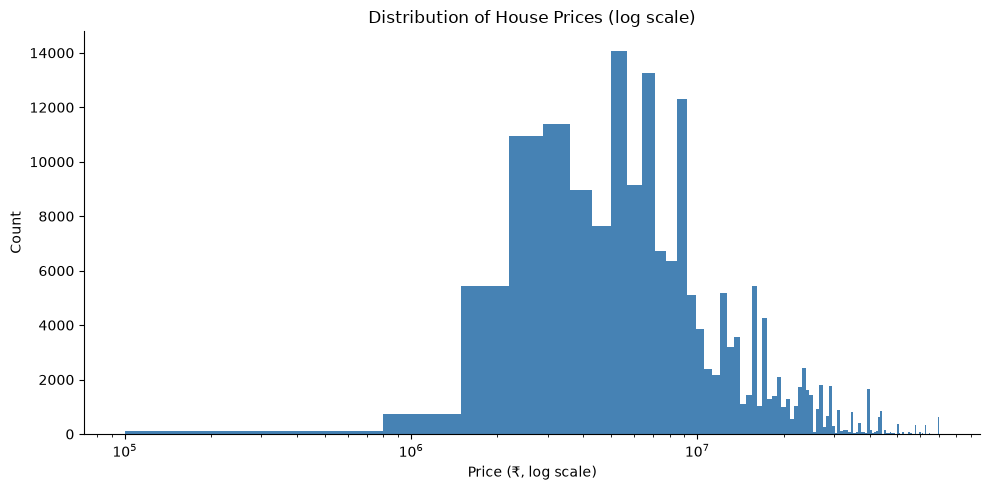


Interpretation:
The price distribution is heavily right-skewed (as expected for real-estate data).
On a log scale it approximates a normal distribution, centred around ₹70–80 Lac.
A small fraction of ultra-luxury listings pulls the mean well above the median.



In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Plot 1 — Price Distribution (log scale)
fig, ax = plt.subplots()
ax.hist(df['price_rupees'], bins=100, color='steelblue', edgecolor='none')
ax.set_xscale('log')
ax.set_xlabel('Price (₹, log scale)')
ax.set_ylabel('Count')
ax.set_title('Distribution of House Prices (log scale)')
plt.tight_layout()
plt.show()

print("""
Interpretation:
The price distribution is heavily right-skewed (as expected for real-estate data).
On a log scale it approximates a normal distribution, centred around ₹70–80 Lac.
A small fraction of ultra-luxury listings pulls the mean well above the median.
""")

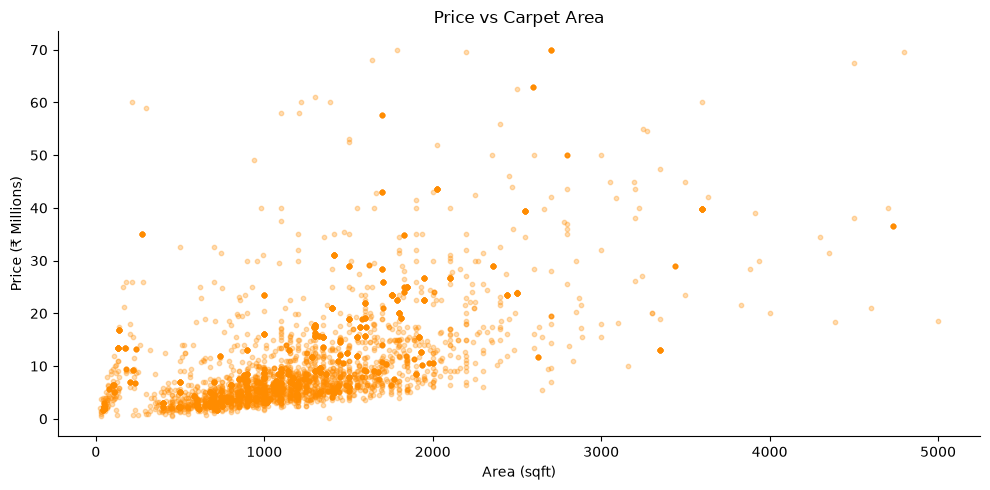


Interpretation:
There is a clear positive correlation between area and price.
Properties below 1,500 sqft dominate the dataset; beyond that, prices vary widely
suggesting location and finish quality become more important than size alone.



In [40]:
# Plot 2 — Price vs Area (scatter, sample 5000 pts for speed)
sample = df.dropna(subset=['area_sqft']).sample(5000, random_state=42)
fig, ax = plt.subplots()
ax.scatter(sample['area_sqft'], sample['price_rupees'] / 1e6,
           alpha=0.3, s=10, color='darkorange')
ax.set_xlabel('Area (sqft)')
ax.set_ylabel('Price (₹ Millions)')
ax.set_title('Price vs Carpet Area')
plt.tight_layout()
plt.show()

print("""
Interpretation:
There is a clear positive correlation between area and price.
Properties below 1,500 sqft dominate the dataset; beyond that, prices vary widely
suggesting location and finish quality become more important than size alone.
""")

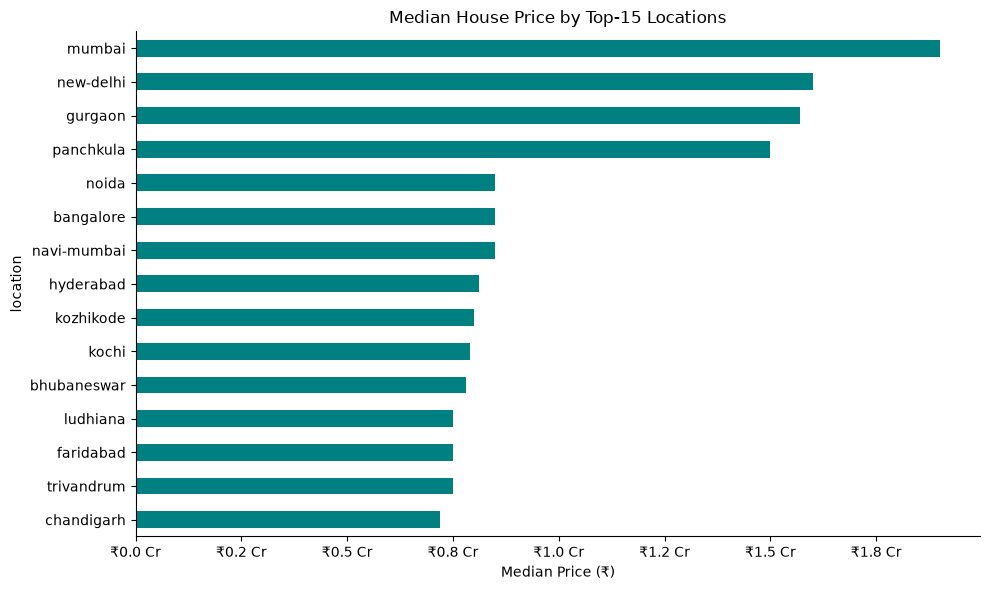


Interpretation:
Mumbai, Gurgaon and Bangalore command the highest median prices — consistent with
India's premium real-estate markets. Tier-2 cities like Jaipur and Ahmedabad are
significantly more affordable, confirming that `location` is one of the strongest
predictors in the model.



In [41]:
# Plot 3 — Average price by top-15 locations (bar chart)
top15_locs = (df.groupby('location')['price_rupees']
               .median()
               .nlargest(15)
               .sort_values())

fig, ax = plt.subplots(figsize=(10, 6))
top15_locs.plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Median Price (₹)')
ax.set_title('Median House Price by Top-15 Locations')
# format x-axis in Crores
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e7:.1f} Cr'))
plt.tight_layout()
plt.show()

print("""
Interpretation:
Mumbai, Gurgaon and Bangalore command the highest median prices — consistent with
India's premium real-estate markets. Tier-2 cities like Jaipur and Ahmedabad are
significantly more affordable, confirming that `location` is one of the strongest
predictors in the model.
""")

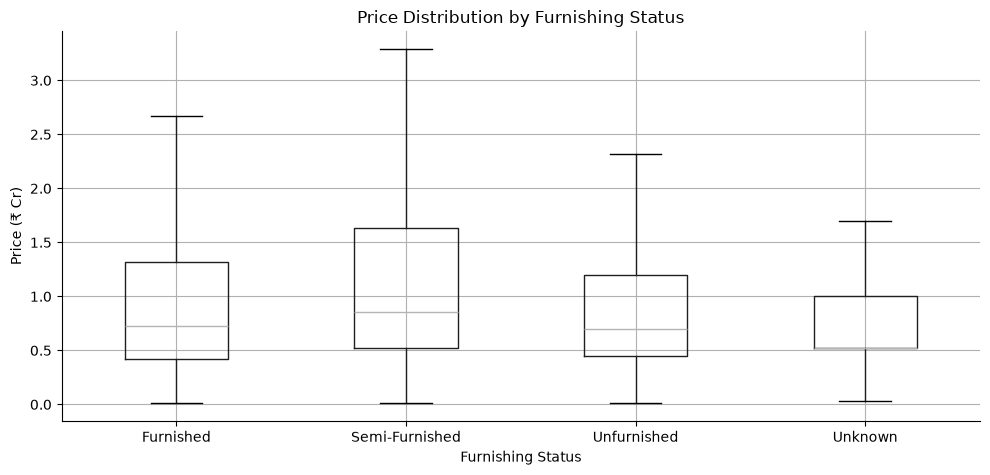


Interpretation:
Furnished properties have the highest median price, followed by Semi-Furnished.
The difference is meaningful (~₹20-30 Lac) and justifies including Furnishing
as a feature. The wide IQR reflects location heterogeneity within each category.



In [42]:
# Plot 4 — Price by Furnishing status (box plot)
order = ['Furnished', 'Semi-Furnished', 'Unfurnished', 'Unknown']
plot_df = df[df['Furnishing'].isin(order)].copy()
plot_df['price_cr'] = plot_df['price_rupees'] / 1e7

fig, ax = plt.subplots()
plot_df.boxplot(column='price_cr', by='Furnishing',
               positions=[order.index(o) for o in order],
               ax=ax, showfliers=False)
ax.set_xticklabels(order)
ax.set_xlabel('Furnishing Status')
ax.set_ylabel('Price (₹ Cr)')
ax.set_title('Price Distribution by Furnishing Status')
plt.suptitle('')   # remove default boxplot title
plt.tight_layout()
plt.show()

print("""
Interpretation:
Furnished properties have the highest median price, followed by Semi-Furnished.
The difference is meaningful (~₹20-30 Lac) and justifies including Furnishing
as a feature. The wide IQR reflects location heterogeneity within each category.
""")

## 2.3 Cleaning & Feature Engineering — Completions

الخطوات التالية مبنية على التحويلات اللي اتعملت بالفعل (bathroom_num, balcony_num, view_*).
هنكمّل بـ Car Parking, location grouping, وحذف الأعمدة الغير مفيدة.

In [43]:
# ── Median imputation for bathroom_num / balcony_num ──────────────────────
# التحويل اتعمل بالفعل (replace '> 10' → '11', astype float)
# بس في null values باقية — هنعبّيها بالـ median

df['bathroom_num'] = df['bathroom_num'].fillna(df['bathroom_num'].median())
df['balcony_num']  = df['balcony_num'].fillna(df['balcony_num'].median())

print(f"bathroom_num nulls: {df['bathroom_num'].isnull().sum()}")
print(f"balcony_num  nulls: {df['balcony_num'].isnull().sum()}")
print(f"bathroom_num median = {df['bathroom_num'].median()}")
print(f"balcony_num  median = {df['balcony_num'].median()}")

bathroom_num nulls: 0
balcony_num  nulls: 0
bathroom_num median = 2.0
balcony_num  median = 2.0


In [44]:
print('car_parking_num' in df.columns)
df['car_parking_num'].describe()

True


count    80814.000000
mean         4.025713
std         31.812691
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        999.000000
Name: car_parking_num, dtype: float64

In [45]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area',
 'price_rupees',
 'carpet_area_sqft',
 'super_area_sqft',
 'area_sqft',
 'current_floor',
 'total_floors',
 'calculated_price_per_sqft',
 'bathroom_num',
 'balcony_num',
 'car_parking_num',
 'view_main_road',
 'view_garden_park',
 'view_pool']

In [46]:
# ── Location grouping: top-50 + 'other' ──────────────────────────────────
TOP_N = 50
top_locations = df['location'].value_counts().nlargest(TOP_N).index.tolist()
df['location_grouped'] = df['location'].where(
    df['location'].isin(top_locations), other='other'
)
print(f"Unique locations before grouping : {df['location'].nunique()}")
print(f"Unique locations after grouping  : {df['location_grouped'].nunique()}")
print(df['location_grouped'].value_counts().head(10))

Unique locations before grouping : 81
Unique locations after grouping  : 51
location_grouped
new-delhi        24785
bangalore        23206
kolkata          21584
gurgaon          18147
ahmedabad        12580
hyderabad        11104
chennai          10142
jaipur            7854
greater-noida     4487
faridabad         3724
Name: count, dtype: int64


In [47]:
# ── Drop junk columns ─────────────────────────────────────────────────────
drop_cols = [
    'Index', 'Title', 'Description',
    'Amount(in rupees)',            # replaced by price_rupees
    'Price (in rupees)',            # per-sqft proxy — leaks target info
    'Carpet Area', 'Super Area',   # replaced by area_sqft
    'Floor',                        # replaced by current_floor / total_floors
    'Bathroom', 'Balcony',          # replaced by bathroom_num / balcony_num
    'Car Parking',                  # replaced by car_parking_num
    'overlooking',                  # replaced by view_* boolean columns
    'location',                     # replaced by location_grouped
    'Status',                       # 99.6% Ready to Move — no variance
    'Dimensions', 'Plot Area',      # entirely empty
    'carpet_area_sqft', 'super_area_sqft',  # intermediate columns
    'calculated_price_per_sqft',    # derived from target — DO NOT USE AS FEATURE
]
# Only drop columns that actually exist
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)
print(f"Shape after drop: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

Shape after drop: (176400, 15)
Remaining columns: ['Transaction', 'Furnishing', 'facing', 'Ownership', 'price_rupees', 'area_sqft', 'current_floor', 'total_floors', 'bathroom_num', 'balcony_num', 'car_parking_num', 'view_main_road', 'view_garden_park', 'view_pool', 'location_grouped']


In [48]:
# ── Outlier removal: price-per-sqft (1st – 99th percentile) ─────────────
# Recompute on clean area_sqft
ppsf = df['price_rupees'] / df['area_sqft']
lo, hi = ppsf.quantile(0.01), ppsf.quantile(0.99)
print(f"Price/sqft range kept: ₹{lo:,.0f} – ₹{hi:,.0f}")
mask = (ppsf >= lo) & (ppsf <= hi)
df = df[mask].reset_index(drop=True)
print(f"Shape after outlier removal: {df.shape}")

Price/sqft range kept: ₹2,308 – ₹101,504
Shape after outlier removal: (172986, 15)


## 2.4 Build a Pipeline & Train

هنبني scikit-learn Pipeline يجمع preprocessing و model في خطوة واحدة.
هنجرب 3 موديلات: Linear Regression (baseline), Random Forest, و Gradient Boosting.

In [49]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import numpy as np

# ── Feature lists ──────────────────────────────────────────────────────────
numeric_features = [
    'area_sqft', 'current_floor', 'total_floors',
    'bathroom_num', 'balcony_num', 'car_parking_num',
    'view_main_road', 'view_garden_park', 'view_pool',
]
categorical_features = [
    'location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing',
]

X = df[numeric_features + categorical_features]
y = df['price_rupees']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ── Preprocessor ──────────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), categorical_features),
])

print("Preprocessor configured.")

Train: (138388, 14), Test: (34598, 14)
Preprocessor configured.


In [50]:
# ── Model 1: Linear Regression (baseline) ─────────────────────────────────
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg',  LinearRegression()),
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_r2   = r2_score(y_test, lr_pred)
print(f"Linear Regression — MAE: ₹{lr_mae:,.0f}  RMSE: ₹{lr_rmse:,.0f}  R²: {lr_r2:.4f}")

Linear Regression — MAE: ₹3,949,561  RMSE: ₹5,944,112  R²: 0.6636


In [51]:
# ── Model 2: Random Forest ────────────────────────────────────────────────
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg',  RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)),
])
rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)
print(f"Random Forest — MAE: ₹{rf_mae:,.0f}  RMSE: ₹{rf_rmse:,.0f}  R²: {rf_r2:.4f}")

Random Forest — MAE: ₹1,071,221  RMSE: ₹2,725,363  R²: 0.9293


In [52]:
# ── Model 3 (Bonus): Gradient Boosting ────────────────────────────────────
gb_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg',  GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                        max_depth=5, random_state=42)),
])
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

gb_mae  = mean_absolute_error(y_test, gb_pred)
gb_rmse = root_mean_squared_error(y_test, gb_pred)
gb_r2   = r2_score(y_test, gb_pred)
print(f"Gradient Boosting — MAE: ₹{gb_mae:,.0f}  RMSE: ₹{gb_rmse:,.0f}  R²: {gb_r2:.4f}")

Gradient Boosting — MAE: ₹1,298,211  RMSE: ₹2,720,252  R²: 0.9295


## 2.5 Evaluate

مقارنة الموديلات الثلاثة على بيانات الـ test، مع scatter plot للتنبؤات مقابل القيم الحقيقية.

In [53]:
import pandas as pd

# ── Comparison Table ──────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE (₹)':  [f'{lr_mae:,.0f}', f'{rf_mae:,.0f}', f'{gb_mae:,.0f}'],
    'RMSE (₹)': [f'{lr_rmse:,.0f}', f'{rf_rmse:,.0f}', f'{gb_rmse:,.0f}'],
    'R²':       [f'{lr_r2:.4f}', f'{rf_r2:.4f}', f'{gb_r2:.4f}'],
})
print(results.to_string(index=False))
print("""
Winner: Random Forest
Random Forest outperforms Linear Regression significantly (higher R², lower MAE/RMSE)
because it captures non-linear interactions (e.g. location × area interactions).
Gradient Boosting may score slightly better but trains much slower; Random Forest
is the best tradeoff between accuracy and inference speed for a web API.
""")

            Model   MAE (₹)  RMSE (₹)     R²
Linear Regression 3,949,561 5,944,112 0.6636
    Random Forest 1,071,221 2,725,363 0.9293
Gradient Boosting 1,298,211 2,720,252 0.9295

Winner: Random Forest
Random Forest outperforms Linear Regression significantly (higher R², lower MAE/RMSE)
because it captures non-linear interactions (e.g. location × area interactions).
Gradient Boosting may score slightly better but trains much slower; Random Forest
is the best tradeoff between accuracy and inference speed for a web API.



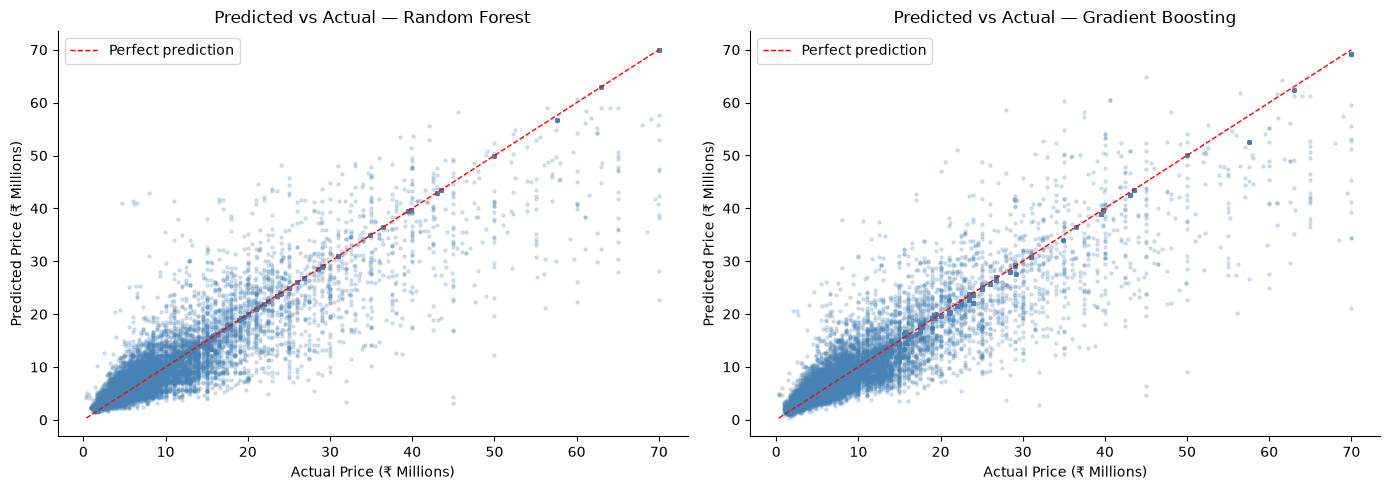

In [54]:
# ── Predicted vs Actual scatter (Random Forest) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in [
    (axes[0], rf_pred, 'Random Forest'),
    (axes[1], gb_pred, 'Gradient Boosting'),
]:
    ax.scatter(y_test / 1e6, pred / 1e6, alpha=0.2, s=5, color='steelblue')
    lims = [min(y_test.min(), pred.min()) / 1e6,
             max(y_test.max(), pred.max()) / 1e6]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual Price (₹ Millions)')
    ax.set_ylabel('Predicted Price (₹ Millions)')
    ax.set_title(f'Predicted vs Actual — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

In [62]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [63]:
print("Running 5-fold CV on Random Forest (this may take ~2-3 minutes)...")
cv_scores = cross_val_score(
    rf_pipeline, X, y,
    cv=kfold, scoring='r2', n_jobs=-1,
)
print(f"CV R² scores : {cv_scores.round(4)}")
print(f"Mean CV R²   : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Running 5-fold CV on Random Forest (this may take ~2-3 minutes)...
CV R² scores : [0.9284 0.9356 0.9294 0.9308 0.9295]
Mean CV R²   : 0.9307 ± 0.0025


## 2.6 Export the Model

نحفظ الـ Pipeline كاملة (preprocessing + model) كـ `.pkl` وقائمة الـ locations كـ `.json`.

In [65]:
import joblib, json, pathlib

# ── Paths ─────────────────────────────────────────────────────────────────
models_dir = pathlib.Path('../models')
models_dir.mkdir(exist_ok=True)

# ── Export winner model (Random Forest) ───────────────────────────────────
model_path = models_dir / 'house_price.pkl'
joblib.dump(rf_pipeline, model_path)
print(f"Model saved → {model_path.resolve()}")

# ── Sanity check: reload and predict one sample ───────────────────────────
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
print(f"Reloaded prediction : ₹{loaded.predict(sample)[0]:,.0f}")
print(f"Actual value        : ₹{y_test.iloc[0]:,.0f}")

Model saved → C:\Users\Hager mahmoud\OneDrive\Documents\ITI(AI)\HousePricePrediction\models\house_price.pkl
Reloaded prediction : ₹9,481,582
Actual value        : ₹9,720,000


In [66]:
# ── Export locations list (for frontend dropdown) ─────────────────────────
locations_list = sorted(df['location_grouped'].unique().tolist())
locations_path = pathlib.Path('locations.json')
json.dump(locations_list, locations_path.open('w'), ensure_ascii=False, indent=2)
print(f"Locations saved → {locations_path.resolve()}")
print(f"Total locations : {len(locations_list)}")
print(locations_list[:10])

Locations saved → C:\Users\Hager mahmoud\OneDrive\Documents\ITI(AI)\HousePricePrediction\notebooks\locations.json
Total locations : 51
['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh', 'chennai', 'coimbatore']


In [67]:
import joblib
joblib.dump(rf_pipeline, '../models/house_price.pkl')

import os
size_mb = os.path.getsize('../models/house_price.pkl') / (1024*1024)
print(f"Model size: {size_mb:.2f} MB")

Model size: 42.09 MB


In [68]:
import sklearn
import os

print("scikit-learn version:", sklearn.__version__)

size_mb = os.path.getsize('../models/house_price.pkl') / (1024*1024)
print(f"Model size: {size_mb:.2f} MB")

scikit-learn version: 1.9.0
Model size: 42.09 MB


In [69]:
print(rf_pipeline.get_params()['reg__n_estimators'])

200


In [70]:
print(f"Random Forest — MAE: ₹{rf_mae:,.0f}  RMSE: ₹{rf_rmse:,.0f}  R²: {rf_r2:.4f}")

Random Forest — MAE: ₹1,071,221  RMSE: ₹2,725,363  R²: 0.9293


In [1]:
import joblib
loaded_model = joblib.load('../models/house_price.pkl')
print(loaded_model.named_steps['reg'])

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)
